# Halo transports for a sharded shallow water model

*Five ways to move the same halo, one adjoint written by nobody.*

FESOM2-JAX (arXiv:2608.01546, Sect. 2.2–2.3) makes one design decision and gets a
distributed adjoint out of it for free. The decision: **write the halo exchange in JAX**,
out of primitives whose transposes JAX already knows — `all_gather`, `all_to_all`,
`ppermute`, gather, `where` — inside a `jax.shard_map` over a 1-D device axis. Nothing
about the exchange is a black box to the AD system, so `jax.grad` walks straight through
it and the reverse exchange is *derived*, not written. Their phrase for the result is
**"an exact adjoint costs nothing"**: the four transports they compare differ in speed
and in bytes, but not one of them needed a hand-written backward pass, and the exact ones
are not the slow ones.

They compare four transports along two axes:

| transport | what crosses the wire | adjoint | volume vs $P$ |
|---|---|---|---|
| **all-gather** | the whole field, to every device | automatic, exact | $O(P)$ — the baseline |
| **padded all-to-all** | one fixed-width slot per peer, zero-filled | automatic, exact | $O(\text{halo})$, with a pad factor that grows |
| **coloured `ppermute`** | one partner per round, $K$ rounds | automatic, exact | $O(\text{halo})$, flat in $P$; pays $K$ latencies |
| **ragged all-to-all** | exactly the needed entries | **defective transpose rule in their JAX → forward-only** | $O(\text{halo})$, minimal |

Their findings: small mesh → ragged/padded win (latency-bound); large mesh → coloured
wins (bandwidth-bound); the gradient step costs 4.7× the forward, and memory, not time,
is what binds.

**What changes on a structured torus.** This notebook redoes all of it on the
shallow-water model of `nb01`, decomposed as an $R_x \times R_y$ periodic torus over a
1-D device axis. Three things move:

1. **Corners are mandatory.** The nine-point stencil reads the diagonal cell, so every
   transport must deliver four faces *and* four corners (`nb04` §1). FESOM's unstructured
   halo has no notion of a corner; here it is the thing that decides the schedule.
2. **The neighbour graph is regular.** Each of the eight directions is already a *full*
   permutation of the devices, so the edge-colouring FESOM computes greedily is free —
   and a second schedule becomes available that an unstructured mesh cannot express: the
   **two-phase** exchange, ±x then ±y on the *already refreshed* array, which delivers
   the corners in the face messages. $K = 4$ instead of $8$.
3. **The pad factor stops growing.** Neighbour degree is capped at 8, so the padded
   transport's waste saturates instead of running away to FESOM's 40× at $P = 128$.

Everything below runs on 8 fake CPU devices in one process, `jax 0.6.2`, `x64` on, with
GT4Py's `operators.timestep` as the stencil inside the `shard_map` body. Timings from
that arrangement rank latency against volume *qualitatively at best* — §8 says what has
to be measured on real hardware, and provides the empty columns for it.

In [1]:
import os

# Notebook-local, so the notebook is reproducible standalone. The harness itself pins
# neither: bench_transports.py and swm_battery.py take the device count from jax.devices().
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=8")

import inspect
import json
import re
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import swm_battery as B
import swm_sharded as S
from halo_transports import Layout, get_transport, true_halo_cells
from hlo_accounting import bytes_moved, collectives_in
from jax_compat import shard_map, shard_map_api

BLUE, ORANGE, MAGENTA = "#1f6fb4", "#d1590a", "#b03a6f"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

TRANSPORTS = ["allgather", "padded", "coloured8", "coloured2ph", "ragged", "ragged_emul"]
LAYOUTS = ["1x1", "2x1", "1x2", "2x2", "4x2", "2x4"]
LAY = {s: Layout(S.M, S.N, *(int(v) for v in s.split("x"))) for s in LAYOUTS}

# One row per (transport, layout), written by bench_transports.py:
#   JAX_PLATFORMS=cpu XLA_FLAGS=--xla_force_host_platform_device_count=8 \
#     python examples/next/swm/bench_transports.py --transports all \
#         --layouts 1x1,2x1,1x2,2x2,4x2,2x4 --out ../../../../tmp/laptop_results.jsonl
CANDIDATES = [Path("laptop_results.jsonl"), Path("../../../../tmp/laptop_results.jsonl")]
RESULTS = next((p for p in CANDIDATES if p.exists()), None)
if RESULTS is None:
    raise FileNotFoundError(f"no benchmark results; looked in {[str(p) for p in CANDIDATES]}")
ROWS = [json.loads(x) for x in RESULTS.read_text().splitlines() if x.strip()]
R = {(r["transport"], r["layout"]): r for r in ROWS}
E = ROWS[0]

print(f"live kernel : jax {jax.__version__}, {jax.device_count()} x "
      f"{jax.devices()[0].device_kind}, shard_map via {shard_map_api()}")
print(f"results file: {RESULTS}  ({len(ROWS)} rows)")
print(f"  measured on: jax {E['jax']}, {E['n_devices']} {E['platform']} devices, "
      f"{E['n_processes']} process, n_steps={E['n_steps']}, "
      f"grid {E['M']}x{E['N']}, gt4py tracer dispatch: {E['gt4py_tracer_dispatch']}")

live kernel : jax 0.6.2, 8 x cpu, shard_map via jax.shard_map(check_vma=)
results file: ../../../../tmp/laptop_results.jsonl  (36 rows)
  measured on: jax 0.6.2, 8 cpu devices, 1 process, n_steps=10, grid 16x16, gt4py tracer dispatch: not needed


## 2. The interface, and the battery that gates it

A transport is one object with three methods. `prepare(layout)` runs once, outside `jit`,
and returns whatever static NumPy tables the exchange needs. `exchange(a_local, tables,
axis_name)` runs *inside* the `shard_map` body on this device's `(MLOC+2, NLOC+2)` array
and returns the same shape with all eight halo neighbourhoods refreshed. The contract has
exactly one prohibition, and it is the whole point: **no `custom_vjp`, no
`pure_callback`** — only `jax.lax` collectives and array ops, so that `jax.vjp`
transposes the thing without being told how. `wire_cells(tables)` is the number of cells
this device puts on the wire per exchange, read off the tables.

Nine tests gate every transport. They fall into three groups.

| | test | what it establishes |
|---|---|---|
| **exchange alone** | T1 `exchange_forward` | the exchange equals `np.pad(interior, 1, "wrap")` per rank, **exactly** |
| | T2 `exchange_dotproduct` | $\langle Lx, y\rangle = \langle x, L^{\mathsf T}y\rangle$ through `jax.vjp`, *and* agreement with `halo_lib`'s independently built dense $L^{\mathsf T}$ (`nb04` §2) |
| | T0 `oracle_gate` | forward `array_equal` against the `allgather` oracle; adjoint of $\sum w\cdot\text{exchange}(x)$ within 1e-12 relative — FESOM's own gate |
| **model** | T3 `bit_identity_P1` | the sharded program on **one** device reproduces the single-device model **bit for bit** — a statement about the *partitioner*, since both sides run the same GT4Py step |
| | T4 `forward_P` | sharded on $P$ devices vs single-device, relative ≤ 1e-12; also vs an **independent** pure-`jnp.roll` model that shares no code with the GT4Py path |
| | T5 `gradient` | `grad(cost ∘ sharded)` vs `grad(cost ∘ single-device)`, relative ≤ 1e-10 to the largest gradient component |
| | T6 `taylor` | $\lvert J(x+hd) - J(x) - h\langle g,d\rangle\rvert$ halves to second order, rate → 2.00 |
| **cost** | T7 `hlo` | collectives and bytes out of the compiled module, plus the table-derived volume |
| | T8 `timing` | wall time of forward and `value_and_grad` |

T3 and T5 are FESOM's two verification invariants, and the reason the list starts with
the exchange in isolation is theirs too: a distributed adjoint that is wrong is almost
always wrong in the exchange, and the dot-product test on the exchange alone costs
nothing (`nb04` §4).

In [2]:
gate = B.oracle_gate(get_transport("coloured2ph"), LAY["2x2"])
print("oracle_gate(coloured2ph, 2x2)")
for k, v in gate.items():
    print(f"   {k:<20} {v}")

print(f"\nFESOM's two invariants, every transport, worst over all layouts:")
print(f"{'transport':<13}{'T3 P=1 bit-identical':>22}{'T4 fwd vs 1-device':>21}"
      f"{'T4 vs roll ref':>17}{'T5 grad vs 1-device':>22}")
for n in TRANSPORTS:
    rs = [R[(n, s)] for s in LAYOUTS if (n, s) in R]
    ok = [r for r in rs if r["T3_pass"]]
    if not ok:
        print(f"{n:<13}{'does not compile on XLA:CPU (verbatim in section 6)':>82}")
        continue
    t3 = max(r["T3_max_abs_diff"] for r in ok)
    t4 = max(r["T4_max_rel_diff"] for r in rs if r["T4_pass"])
    ti = max(r["T4_indep_max_rel_diff"] for r in rs if r["T4_pass"])
    t5 = max(r["T5_max_rel_diff"] for r in rs if r["T5_pass"])
    print(f"{n:<13}{('exact, %g' % t3):>22}{t4:>21.2e}{ti:>17.2e}{t5:>22.2e}")
print(f"\nT5 noise floor (two single-device implementations, forward bit-identical): "
      f"{R[('allgather', '2x2')]['T5_noise_floor_rel']:.2e} relative")

oracle_gate(coloured2ph, 2x2)
   oracle               allgather
   self_comparison      False
   fwd_array_equal      True
   fwd_max_abs_diff     0.0
   grad_max_rel_diff    3.9793030658490065e-17
   pass                 True

FESOM's two invariants, every transport, worst over all layouts:
transport      T3 P=1 bit-identical   T4 fwd vs 1-device   T4 vs roll ref   T5 grad vs 1-device
allgather                  exact, 0             6.82e-15         6.82e-15              9.66e-12
padded                     exact, 0             0.00e+00         1.45e-17              8.41e-12
coloured8                  exact, 0             0.00e+00         1.45e-17              8.41e-12
coloured2ph                exact, 0             0.00e+00         1.45e-17              9.66e-12
ragged                                      does not compile on XLA:CPU (verbatim in section 6)
ragged_emul                exact, 0             0.00e+00         1.45e-17              8.41e-12

T5 noise floor (two single-device 

`self_comparison False` on the first block says `coloured2ph` is being measured against a
different transport; `fwd_array_equal True` says the two produce **bit-identical**
forwards despite sharing no collective, and `grad_max_rel_diff` puts their adjoints
within a few times 1e-17 of each other. Bit equality, not a tolerance, is FESOM's forward
gate and it is met by every transport here.

T3 is exact for every transport that runs, at every layout — but read it for what it is.
Both sides of T3 call the *same* GT4Py `timestep`; what it establishes is that **SPMD
partitioning at $P=1$ changes nothing**, a statement about the partitioner, not about the
model. FESOM enforces it strictly and so does this battery, and §7 says what happens when
it is violated.

The independent statement is the last column, `T4 vs roll ref`: the sharded result against
`roll_reference_program`, a pure-`jnp.roll` single-device model in `swm_sharded.py` that
shares no code with the GT4Py path and deliberately associates the arithmetic differently
($x/dx$ rather than $(1/dx)\,x$; one fused $0.25(\cdot)$ rather than two nested
$0.5(\cdot)$). That reference differs from the GT4Py one by 5.55e-17 in $u$ and $v$ — one
ulp of re-association — and is bit-identical in $p$. Against it the distributed model lands
at 1.45e-17 for every transport but `allgather`, which lands at 6.82e-15: the same split
T4 shows against the GT4Py reference, now with a witness that could have disagreed.

The T5 column is the interesting one, and it needs the last line to read. Every transport
lands at 5–10e-12 relative against the single-device gradient, and the noise floor is
2.8e-12: that is the spread between **two single-device implementations that are forward
bit-identical** and differ only in the order the adjoint accumulates. The distributed
gradient sits a small multiple above a floor it cannot get under. This gradient is
cancellation-limited, not transport-limited — quoting 6e-12 as "the error of the
distributed adjoint" would be quoting the model's conditioning.

## 3. What each transport puts on the wire

Volume is computed from the **prepared tables**, as FESOM does in `bench_halo_micro`:
`wire_cells(tables)` is the size of the buffer this device hands to its collective, and
the reference is the true halo rim, $2h(M_{loc}+N_{loc}) + 4h^2$ cells. Three fields
(`u`, `v`, `p`), 8 bytes each, one exchange per field per step.

The compiled HLO is the *cross-check*, not the metric — §7 explains why it took two
corrections before it could even play that role.

In [3]:
def wire_bytes(name, spec):
    tr = get_transport(name)
    return 3 * tr.wire_cells(tr.prepare(LAY[spec])) * 8


hdr = f"{'transport':<13}" + "".join(f"{s:>12}" for s in LAYOUTS)
print("table-derived wire volume, bytes per device per step (3 fields)\n" + hdr)
print(f"{'true halo':<13}" + "".join(f"{3 * true_halo_cells(LAY[s]) * 8:>12}" for s in LAYOUTS))
for n in ["allgather", "padded", "coloured8", "coloured2ph", "ragged"]:
    print(f"{n:<13}" + "".join(f"{wire_bytes(n, s):>12}" for s in LAYOUTS))
print("\nratio to the true halo")
print(f"{'P':<13}" + "".join(f"{LAY[s].P:>12}" for s in LAYOUTS))
for n in ["allgather", "padded", "coloured8", "coloured2ph", "ragged"]:
    print(f"{n:<13}" + "".join(
        f"{wire_bytes(n, s) / (3 * true_halo_cells(LAY[s]) * 8):>12.2f}" for s in LAYOUTS))

print("\nHLO cross-check (bytes/device/step out of the compiled module, 1 step)")
print(f"{'transport':<13}" + "".join(f"{s:>12}" for s in LAYOUTS))
for n in TRANSPORTS:
    print(f"{n:<13}" + "".join(
        f"{str(R[(n, s)]['hlo_fwd_bytes']):>12}" for s in LAYOUTS))

table-derived wire volume, bytes per device per step (3 fields)
transport             1x1         2x1         1x2         2x2         4x2         2x4
true halo            1632        1248        1248         864         672         672
allgather            6144        6144        6144        6144        6144        6144
padded               1632        1728        1728        1536        1536        1536
coloured8            1632        1248        1248         864         672         672
coloured2ph          1632        1248        1248         864         672         672
ragged               1632        1248        1248         864         672         672

ratio to the true halo
P                       1           2           2           4           8           8
allgather            3.76        4.92        4.92        7.11        9.14        9.14
padded               1.00        1.38        1.38        1.78        2.29        2.29
coloured8            1.00        1.00        1.00   

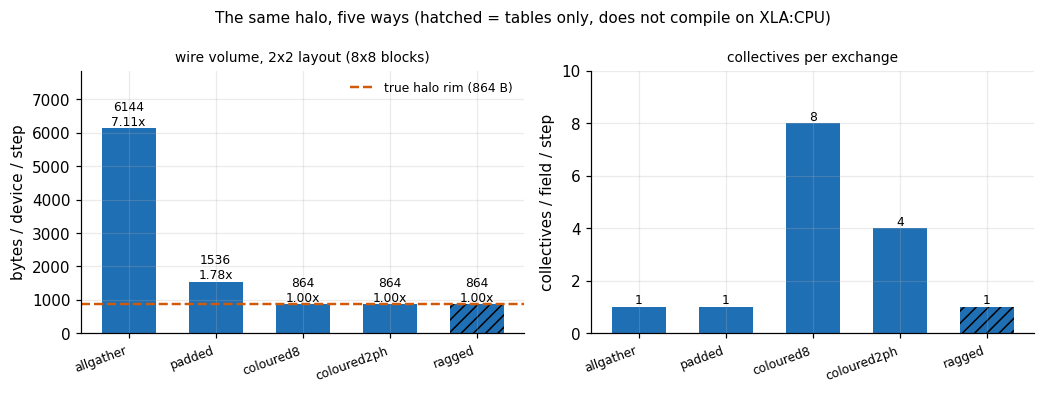

In [4]:
spec = "2x2"
shown = ["allgather", "padded", "coloured8", "coloured2ph", "ragged"]
vol = [wire_bytes(n, spec) for n in shown]
true_b = 3 * true_halo_cells(LAY[spec]) * 8
# collectives per field per step: from the compiled module where it compiles, and from the
# schedule where it does not (ragged is one ragged_all_to_all per field, uncompilable here).
K = {n: R[(n, spec)]["collectives_fwd"] // 3 for n in shown if R[(n, spec)]["collectives_fwd"]}
K["ragged"] = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.6))
xs = np.arange(len(shown))
bars = ax1.bar(xs, vol, color=BLUE, width=0.62)
bars[shown.index("ragged")].set_hatch("///")
ax1.axhline(true_b, color=ORANGE, lw=1.6, ls="--", label=f"true halo rim ({true_b} B)")
for x, v in zip(xs, vol):
    ax1.text(x, v, f"{v}\n{v / true_b:.2f}x", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(xs); ax1.set_xticklabels(shown, rotation=20, ha="right", fontsize=8)
ax1.set_ylabel("bytes / device / step"); ax1.set_ylim(0, max(vol) * 1.28)
ax1.set_title(f"wire volume, {spec} layout ({LAY[spec].MLOC}x{LAY[spec].NLOC} blocks)", fontsize=9)
ax1.legend(fontsize=8, frameon=False, loc="upper right")

bars2 = ax2.bar(xs, [K[n] for n in shown], color=BLUE, width=0.62)
bars2[shown.index("ragged")].set_hatch("///")
for x, n in zip(xs, shown):
    ax2.text(x, K[n], str(K[n]), ha="center", va="bottom", fontsize=8)
ax2.set_xticks(xs); ax2.set_xticklabels(shown, rotation=20, ha="right", fontsize=8)
ax2.set_ylabel("collectives / field / step"); ax2.set_ylim(0, max(K.values()) * 1.25)
ax2.set_title("collectives per exchange", fontsize=9)
fig.suptitle("The same halo, five ways (hatched = tables only, does not compile on XLA:CPU)",
             fontsize=10)
fig.tight_layout()
plt.show()

Read the two panels together and FESOM's central point falls out: **bytes and messages
are different currencies, and no transport is best in both.** `allgather` moves 7×
the halo in one collective; `coloured8` moves exactly the halo in eight; `padded` is
between on both counts; `coloured2ph` is on the volume floor at half `coloured8`'s
message count. §5 measures what that trade is worth.

### 3.1 `allgather` — the oracle

`lax.all_gather` of the flattened interior lanes, `(P, MLOC*NLOC)` on every device, then
a fancy-index gather with two static int32 maps (`Layout.owner_lane()`) reads *every*
local cell — interior and halo alike — from its owner. No mask, no slicing, no direction
logic; the index pair is the entire schedule. It is the one asymmetric transport: it
*sends* only its own block, $M_{loc}N_{loc}$ cells, which **falls** with $P$, and
*receives* the whole global field, $P M_{loc} N_{loc}$, which does not. `wire_cells`
reports the receive side, because taking delivery of the whole field is what makes this
the $O(P)$ transport: flat at 6144 B, 3.8× the halo at $P=1$ and 9.1× at $P=8$ — the
baseline the others have to beat. Its adjoint is one `reduce-scatter` per field per step, and it is
the transport the others are gated against because it is the one whose correctness is
obvious by inspection.

### 3.2 `padded` — one `all_to_all`, zeros included

Every ordered pair $(d,e)$ gets a slot of `pad_slot` cells — the largest chunk any device
sends any other — so one `lax.all_to_all(tiled=True)` on a `P*pad_slot` buffer moves
every device's boundary at once. The pad factor is a function of the **layout**, not of
$P$: it is the largest single-peer chunk times $P$ over the rim, so it tracks the block's
aspect ratio — 1.00 at `1x1`, 1.38 at `2x1`, 1.78 at `2x2`, 2.29 at `4x2`, and **3.60 at
`8x1`**, which is also a $P=8$ layout. FESOM measured 1.8× at $P=4$ on the unstructured
mesh — the same number as `2x2` here — and theirs climbs to 40.7× at $P=128$ (98.4 %
zeros) because interface size keeps growing with the partition count. On the torus it does
not run away, but it does not settle either: the two $P=8$ layouts differ from each other
by 1.6×. With halo width $h=2$ at `8x1` the padding stops being a rounding error —
`padded` moves 320 cells against `allgather`'s 256, i.e. **worse than shipping the whole
field** — and `8x1`/`1x8` are exactly the layouts the 2-node Santis block runs.

### 3.3 `coloured8` / `coloured2ph` — $K$ permutation rounds

Each round is a **partial permutation** of the devices — nobody sends or receives twice —
which is exactly the legality condition for `lax.ppermute`. `coloured8` is FESOM's
single-phase form: the eight directions are already full permutations of a torus, so
$K=8$ rounds all read the original field and the diagonals carry the corners.
`coloured2ph` exchanges ±x first and then ±y on the *result*, sending edge rows that
include the two halo columns phase 1 just filled, so the corners ride along in the face
messages: $K=4$, at the price of phase 2 depending on phase 1. Both move exactly the halo
rim, ratio 1.00 at every layout — the floor of FESOM's 1.0–1.4×, and it is the torus that
puts them there: every colour class is a full permutation with uniform chunks.

`prepare()` does not assert the schedule; T0 and T1 are what catch a wrong table, by bit
equality with `allgather` and with the wrap-pad on every rank.

### 3.4 `ragged` — the minimal one, which does not run here

`lax.ragged_all_to_all` ships exactly the cells the peers need: one variable-length chunk
per peer, driven by four offset/size tables. Pad factor exactly 1.00. It is also the only
transport in this notebook that never executed — §6.

### Degenerate layouts, and why nobody special-cased them

Three of the six layouts are degenerate, and not one transport has a branch for them.

- **`1x1`.** Every message is a self-message. `allgather`'s index pair becomes a
  relabelling of the device's own lanes; `padded`'s `all_to_all` is deleted outright by
  XLA (0 B in the HLO against 1632 B of table volume, and 0 B is the honest number);
  `ragged`'s chunks become self-sends; `coloured`'s eight perms are all the identity — and
  XLA keeps all eight `collective-permute`s rather than folding them, which is why
  `coloured8` is still 2× `coloured2ph` at 1x1 (§5).
- **`Rx = 2`** (or `Ry = 2`). E and W are the *same* partner. `coloured` sends that peer
  two rounds, each still a legal partial permutation; `ragged` merges both strips into one
  chunk to that peer; `padded`'s slot for the pair simply holds more cells — which is why
  its pad factor at `P=2` (1.38) is worse than at `P=1` (1.00).
- **`Rx = 1`** (or `Ry = 1`). The E/W neighbour *is* the device. `lax.ppermute` accepts
  self-pairs `(i, i)` — verified forward and reverse on jax 0.6.2 **and** 0.11.1 — so those
  rounds stay collectives and the tables need no local-routing branch.

T0/T1/T2 pass on all three on both JAX versions, which is the point of running the whole
grid rather than the interesting quarter of it.

### 3.5 The fifth baseline: GSPMD-automatic `jnp.roll`

The plan listed a fifth path: no `shard_map` at all, just `jnp.roll` on a globally-sharded
array and let GSPMD insert the communication (`nb03` §5). **It is not implemented here,
because it cannot satisfy this interface.** `exchange` runs inside a `shard_map` body,
where the device axis is *manual*: `jnp.roll` on the local array rolls local memory and
communicates nothing. GSPMD partitioning is what happens *instead of* `shard_map`, not
inside it, so the automatic path is a different program shape, not a different transport.

What it would cost is already measured, in `nb03` §5 and §9: for a clean shift GSPMD
emits `collective-permute` of exactly the boundary row — the same shapes, the same
`source_target_pairs` and the same bytes as the hand-written `ppermute` version — so on
volume the compiler ties with `coloured`. Two caveats from that notebook carry over: on a
2-D mesh with diagonals it emits **duplicate** permutes (eight messages where six would
do, a CSE miss), and with `jnp.pad(..., mode="edge")` instead of a wrap it falls off the
recognition path entirely and moves ~17× the necessary volume. The argument for writing
the transport by hand was never that it is faster; it is that the communication stops
depending on whether the compiler recognises your idiom.

In [5]:
import transport_coloured
import transport_padded

print(inspect.getsource(transport_padded.PaddedTransport.exchange))
print(inspect.getsource(transport_coloured._exchange_phase))

    def exchange(self, a_local, tables, axis_name: str):
        r = lax.axis_index(axis_name)
        a_flat = a_local.reshape(-1)
        buf = a_flat[jnp.asarray(tables["send_idx"])[r]]
        recv = lax.all_to_all(buf, axis_name, split_axis=0, concat_axis=0, tiled=True)
        gathered = recv[jnp.asarray(tables["recv_pos"])[r]]
        out = jnp.where(jnp.asarray(tables["halo_mask"]), gathered, a_flat)
        return out.reshape(a_local.shape)

def _exchange_phase(a_flat, ph, axis_name: str):
    buf = a_flat[ph["send_idx"]]
    rounds = [
        lax.ppermute(buf[o : o + s], axis_name, perm=list(p))
        for p, s, o in zip(ph["perms"], ph["slots"], ph["offs"])
    ]
    return jnp.where(ph["halo_mask"], jnp.concatenate(rounds)[ph["recv_pos"]], a_flat)



The last line of those bodies, `set_rim`, is load-bearing for the **transpose**, not for
the forward.

`where(halo_mask, a_flat.at[rim].set(recv[recv_pos]), a_flat)` at the end of `coloured`
(and of `padded` and `ragged`): only the rim is gathered and written, and the `where`
keeps the interior as the *input* array. Forward that is a no-op — every transport's
exchange output is bit-identical to `allgather`'s (§2's T0). Reverse it is not: the
transpose of the `set` is a gather of the `n_rim` rim cotangents, so the interior
cotangent flows straight back and nothing scatter-adds one cotangent per local cell into
the small receive buffer (on GPU that scatter serialises on atomics and made the sharded
gradient 10x the non-sharded one at 1024x1024).

The mask FESOM flags in their `padded` implementation — zeroing the pad slots of the send
buffer before the collective — is *not* needed here, and `transport_padded.py` has none.
The pad slots repeat the index of cell 0, and the transpose of that gather is a
scatter-add, so their cotangents do land on cell 0; but no receiver ever reads a pad slot
(`recv_pos` never points at one), so those cotangents are exactly zero. Forward and
gradient are bit-identical with and without the mask.

It is tempting to blame §2's T4 column on the same line — 6.8e-15 for `allgather` where
everything else is exactly 0.0 — and that would be **wrong**: T4 is a pure forward test,
with no `vjp` anywhere in it. The actual cause is §7's: adding that one `where` to
`allgather` makes its *forward* bit-identical to `padded`'s again, the difference only
appears from `n_steps >= 3`, and it is XLA compiling the scan body differently when the
interior arrives through a dynamic gather rather than as a passed-through array. Same
family as the 16-ulp finding, same operational advice: report it, do not chase it.


## 4. The adjoint nobody wrote

The claim to check is narrow and mechanical: **there is no adjoint code in this
directory.** Not "the adjoint is short", not "the adjoint is generated" — there is no
`custom_vjp`, no `pure_callback`, no backward function, no transposition rule, in any
transport module.

In [6]:
import transport_allgather
import transport_ragged

BANNED = ["custom_vjp", "pure_callback", "defvjp", "custom_jvp", "def _bwd", "transpose_rule"]
PRIMS = ["all_gather", "all_to_all", "ragged_all_to_all", "ppermute", "axis_index", "where"]
print(f"{'module':<22}{'lines':>6}" + "".join(f"{b:>15}" for b in BANNED[:3])
      + "   primitives used")
for m in (transport_allgather, transport_padded, transport_coloured, transport_ragged):
    src = inspect.getsource(m)
    body = "\n".join(x for x in src.splitlines() if not x.lstrip().startswith("#"))
    counts = [body.count(b) for b in BANNED]
    used = [p for p in PRIMS if re.search(rf"\b{p}\(", body)]
    assert sum(counts) == 0, (m.__name__, counts)
    print(f"{m.__name__ + '.py':<22}{len(src.splitlines()):>6}"
          + "".join(f"{c:>15}" for c in counts[:3]) + "   " + ", ".join(used))
print("\nevery banned construct: 0 occurrences in all four modules (asserted above)")

module                 lines     custom_vjp  pure_callback         defvjp   primitives used
transport_allgather.py    50              0              0              0   all_gather, axis_index
transport_padded.py       57              0              0              0   all_to_all, axis_index, where
transport_coloured.py    121              0              0              0   ppermute, where
transport_ragged.py      125              0              0              0   all_gather, ragged_all_to_all, axis_index, where

every banned construct: 0 occurrences in all four modules (asserted above)


In [7]:
print("the adjoint gates, all transports, all layouts")
print(f"{'transport':<13}{'layout':<7}{'T0 fwd':>8}{'T0 adj rel':>12}{'T2 rel':>10}"
      f"{'T2 dense L^T':>14}{'T5 rel':>10}{'T6 rate2':>10}")
for n in TRANSPORTS:
    for s in LAYOUTS:
        r = R[(n, s)]
        if not r["T2_pass"]:
            print(f"{n:<13}{s:<7}{'--- ' + r['T2_status'][:55]}")
            continue
        print(f"{n:<13}{s:<7}{str(r['T0_fwd_array_equal']):>8}"
              f"{r['T0_grad_max_rel_diff']:>12.1e}{r['T2_rel_diff']:>10.1e}"
              f"{r['T2_dense_vjp_diff']:>14.1e}{r['T5_max_rel_diff']:>10.1e}"
              f"{r['T6_rate2_last']:>10.6f}")

the adjoint gates, all transports, all layouts
transport    layout   T0 fwd  T0 adj rel    T2 rel  T2 dense L^T    T5 rel  T6 rate2
allgather    1x1        True     0.0e+00   1.4e-16       0.0e+00   6.1e-12  2.000021
allgather    2x1        True     0.0e+00   8.7e-16       8.9e-16   8.4e-12  2.000021
allgather    1x2        True     0.0e+00   1.5e-16       4.4e-16   6.5e-12  1.999976
allgather    2x2        True     0.0e+00   3.3e-16       0.0e+00   9.3e-12  1.999966
allgather    4x2        True     0.0e+00   1.6e-15       0.0e+00   9.3e-12  1.999948
allgather    2x4        True     0.0e+00   2.8e-16       0.0e+00   9.7e-12  2.000038
padded       1x1        True     0.0e+00   1.4e-16       1.1e-16   6.1e-12  2.000021
padded       2x1        True     1.3e-17   6.5e-16       2.2e-16   8.4e-12  2.000021
padded       1x2        True     6.7e-17   1.5e-16       1.1e-16   6.5e-12  1.999976
padded       2x2        True     1.6e-16   1.7e-16       4.4e-16   8.4e-12  1.999966
padded       4x2  

Four independent statements about the same transpose, and they agree everywhere:

- **T0** — every transport's adjoint equals the `allgather` oracle's to within 2e-16
  relative, and its forward is bit-identical. `allgather` transposes to `reduce-scatter`,
  `padded` to another `all_to_all`, `coloured` to $K$ inverse `ppermute`s. Different
  collectives, same linear map, same numbers.
- **T2** — the dot-product identity through `jax.vjp`, at roundoff, *and* agreement with
  the dense $L^{\mathsf T}$ that `halo_lib` builds message by message in `nb04` §2.2. That
  second one is the real check: it is an independently written transpose, not a
  rearrangement of the same computation.
- **T5** — the sharded gradient against the single-device gradient, at the noise floor.
- **T6** — the Taylor remainder halves quadratically, rate 2.000 ± 5e-5, which says the
  gradient is the gradient *of the function being differentiated* and not of some nearby
  one.

The Taylor test is worth its cost precisely because T0/T2/T5 all compare against something
else that could be wrong in the same way. T6 compares against the model's own values.

## 5. `coloured8` vs `coloured2ph`: identical bytes, half the collectives

This is the cleanest controlled experiment in the notebook. The two schedules move
**exactly the same number of cells** — both sit on the true-halo floor at every layout —
and differ only in how many collectives that takes: 8 rounds of small messages, or 4
rounds of slightly bigger ones (phase 2's rows are $M_{loc}+2h$ wide, carrying the corners).

layout    P  bytes/dev/step   K8   K4   fwd8 ms   fwd4 ms   ratio   grad8 ms   grad4 ms   ratio
1x1       1            1632    8    4    0.0288    0.0136    2.12     0.0686     0.0467    1.47
2x1       2            1248    8    4    0.1646    0.0762    2.16     0.3267     0.1956    1.67
1x2       2            1248    8    4    0.1531    0.0768    1.99     0.3400     0.2031    1.67
2x2       4             864    8    4    0.3451    0.1717    2.01     0.8324     0.4186    1.99
4x2       8             672    8    4    0.7681    0.3806    2.02     1.8000     0.8635    2.08
2x4       8             672    8    4    0.7762    0.4040    1.92     1.9391     0.9051    2.14

forward speed-up of K=4 over K=8: 1.92x - 2.16x;  backward: 1.47x - 2.14x


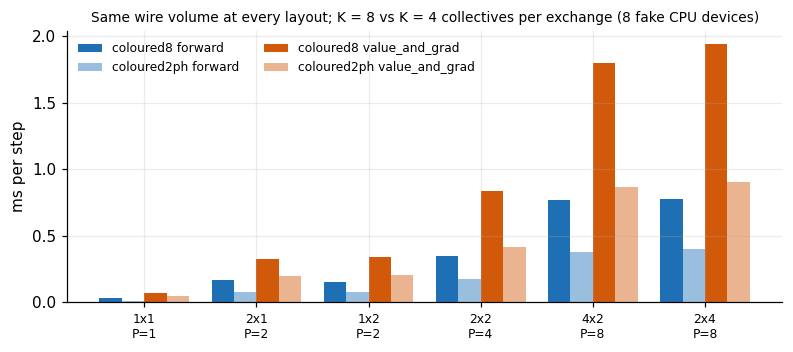

In [8]:
print(f"{'layout':<8}{'P':>3}{'bytes/dev/step':>16}{'K8':>5}{'K4':>5}"
      f"{'fwd8 ms':>10}{'fwd4 ms':>10}{'ratio':>8}{'grad8 ms':>11}{'grad4 ms':>11}{'ratio':>8}")
f8, f4, g8, g4 = [], [], [], []
for s in LAYOUTS:
    a, b = R[("coloured8", s)], R[("coloured2ph", s)]
    assert a["table_bytes"] == b["table_bytes"]
    f8.append(a["fwd_ms_per_step"]); f4.append(b["fwd_ms_per_step"])
    g8.append(a["grad_ms_per_step"]); g4.append(b["grad_ms_per_step"])
    print(f"{s:<8}{a['P']:>3}{a['table_bytes']:>16}{a['collectives_fwd'] // 3:>5}"
          f"{b['collectives_fwd'] // 3:>5}{f8[-1]:>10.4f}{f4[-1]:>10.4f}"
          f"{f8[-1] / f4[-1]:>8.2f}{g8[-1]:>11.4f}{g4[-1]:>11.4f}{g8[-1] / g4[-1]:>8.2f}")
print(f"\nforward speed-up of K=4 over K=8: {min(np.array(f8) / f4):.2f}x - "
      f"{max(np.array(f8) / f4):.2f}x;  backward: {min(np.array(g8) / g4):.2f}x - "
      f"{max(np.array(g8) / g4):.2f}x")

fig, ax = plt.subplots(figsize=(7.4, 3.3))
x = np.arange(len(LAYOUTS)); w = 0.2
ax.bar(x - 1.5 * w, f8, w, color=BLUE, label="coloured8 forward")
ax.bar(x - 0.5 * w, f4, w, color=BLUE, alpha=0.45, label="coloured2ph forward")
ax.bar(x + 0.5 * w, g8, w, color=ORANGE, label="coloured8 value_and_grad")
ax.bar(x + 1.5 * w, g4, w, color=ORANGE, alpha=0.45, label="coloured2ph value_and_grad")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\nP={LAY[s].P}" for s in LAYOUTS], fontsize=8)
ax.set_ylabel("ms per step"); ax.legend(fontsize=8, frameon=False, ncol=2)
ax.set_title("Same wire volume at every layout; K = 8 vs K = 4 collectives per exchange "
             "(8 fake CPU devices)", fontsize=9)
fig.tight_layout()
plt.show()

Volume held exactly equal, halving the collective count buys about a factor of two both
ways. (These are `--repeats 50`. At the harness default of 5 the same ratios scatter over
1.3×–2.9×: microsecond timings on a busy laptop need the repeats.) That is FESOM's CPU lesson — *"count the exchanges before you count the bytes"* —
reproduced with the bytes pinned, which their unstructured mesh could not do: they
observed it as `psum` being $O(P)$ on CPU while `ppermute` stays flat.

**The caveat, in full.** This is eight fake CPU devices inside one process. There is no
network, no NCCL, no PCIe; a `collective-permute` is a memcpy plus dispatch overhead, and
what the factor of two mostly measures is *per-collective dispatch cost*. It is the right
sign for the right reason — fewer messages, less per-message overhead — but the magnitude
on a real fabric is a different number, and on a bandwidth-bound machine with large
blocks the ranking can invert entirely (FESOM: small mesh → latency wins, large mesh →
bandwidth wins). What this table establishes is that the two schedules are *exchangeable*
— same bytes, same results to the last bit — so the comparison on real hardware is a
one-flag experiment.

Note also that $K$ does **not** collapse at 1x1. All eight perms are the identity there,
and XLA keeps eight identity `collective-permute`s rather than folding them away; the
`coloured8` forward at 1x1 is still 2× `coloured2ph`'s for that reason alone.

## 6. Ragged: the transport that could not run, and what was learned anyway

`lax.ragged_all_to_all` is the transport FESOM wanted and could not use: minimal volume,
one variable-length chunk per peer — and a reverse-mode rule they measured as broken
(`docs/JAX_RAGGED_A2A_BUG.md`: violates $\langle f(x),y\rangle = \langle x,f^{\mathsf
T}(y)\rangle$ by $O(1)$, sign-flipped at $P=2$, and $f^{\mathsf T}(\mathbf 1)$ equal to
`axis_size` times the correct answer on an A100). Their conclusion was to make it
forward-only.

Here it did not even compile.

In [9]:
print("ragged, every layout, every test:")
print("   " + R[("ragged", "2x2")]["T1_status"])
print(f"   identical status on {sum(1 for s in LAYOUTS if not R[('ragged', s)]['T1_pass'])}"
      f"/{len(LAYOUTS)} layouts, and on jax 0.6.2 and 0.11.1 alike")

# ragged_emul: the same tables and the same pipeline, with the primitive replaced by a
# pure-jnp transcription of its documented receive semantics (all_gather + a static index
# pair). It validates the tables on a backend that cannot run the primitive.
print(f"\n{'layout':<8}{'send':>10}{'recv_max':>10}{'pad factor':>12}"
      f"{'emul T1':>9}{'emul T2 rel':>13}{'emul T5 rel':>13}")
for s in LAYOUTS:
    t = get_transport("ragged").prepare(LAY[s])
    r = R[("ragged_emul", s)]
    print(f"{s:<8}{t['send_idx'].shape[1]:>10}{t['recv_max']:>10}"
          f"{t['send_idx'].shape[1] / true_halo_cells(LAY[s]):>12.2f}"
          f"{'exact' if r['T1_max_abs_diff'] == 0 else 'FAIL':>9}"
          f"{r['T2_rel_diff']:>13.1e}{r['T5_max_rel_diff']:>13.1e}")

ragged, every layout, every test:
   compile_error: XlaRuntimeError: UNIMPLEMENTED: HLO opcode `ragged-all-to-all` is not supported by XLA:CPU ThunkEmitter
   identical status on 6/6 layouts, and on jax 0.6.2 and 0.11.1 alike

layout        send  recv_max  pad factor  emul T1  emul T2 rel  emul T5 rel
1x1             68        68        1.00    exact      1.4e-16      6.1e-12
2x1             52        52        1.00    exact      6.5e-16      8.4e-12
1x2             52        52        1.00    exact      1.5e-16      6.5e-12
2x2             36        36        1.00    exact      1.7e-16      8.4e-12
4x2             28        28        1.00    exact      2.1e-15      8.4e-12
2x4             28        28        1.00    exact      4.1e-16      8.4e-12


In [10]:
# Does the emulation reproduce the primitive's own docstring example? P=2, the
# configuration FESOM reproduced the bug in.
from jax.sharding import Mesh
from jax.sharding import PartitionSpec as Pspec

from transport_ragged import _emul_tables


def emul_maps(input_offsets, send_sizes, output_offsets, recv_sizes, recv_max):
    """The primitive's documented receive semantics as a static index pair, the same
    construction as transport_ragged._emul_tables: recv[o] = operand_of(src_dev[o])[src_pos[o]]
    where valid[o], with all_to_all(output_offsets) as the local offsets."""
    P = input_offsets.shape[0]
    local_offsets = output_offsets.T
    src_dev = np.zeros((P, recv_max), np.int32)
    src_pos = np.zeros((P, recv_max), np.int32)
    valid = np.zeros((P, recv_max), bool)
    for e in range(P):
        for d in range(P):
            k = np.arange(recv_sizes[e, d], dtype=np.int32)
            o = local_offsets[e, d] + k
            src_dev[e, o], src_pos[e, o], valid[e, o] = d, input_offsets[d, e] + k, True
    return src_dev, src_pos, valid


P_, N_, M_ = 2, 3, 4
io = np.array([[0, 1], [0, 1]], np.int32)
ss = np.array([[1, 2], [1, 1]], np.int32)
oo = np.array([[0, 0], [1, 2]], np.int32)
rs = np.array([[1, 1], [2, 1]], np.int32)
sd, sp, ok = emul_maps(io, ss, oo, rs, M_)
mesh = Mesh(np.array(jax.devices()[:P_]), ("x",))


def body(op):
    r = jax.lax.axis_index("x")
    every = jax.lax.all_gather(op, "x", axis=0, tiled=False)
    return jnp.where(jnp.asarray(ok)[r], every[jnp.asarray(sd)[r], jnp.asarray(sp)[r]], 0.0)


f = jax.jit(shard_map(body, mesh=mesh, in_specs=Pspec("x"), out_specs=Pspec("x")))
got = np.asarray(f(jnp.asarray([1.0, 2.0, 2.0, 3.0, 4.0, 0.0]))).reshape(P_, M_)
want = np.array([[1, 3, 0, 0], [2, 2, 4, 0]], float)
print(f"operand   [[1,2,2],[3,4,0]]  ->  emulation {got.tolist()}")
print(f"lax.ragged_all_to_all docstring says      {want.tolist()}   "
      f"{'MATCH' if np.array_equal(got, want) else 'MISMATCH'}")

operand   [[1,2,2],[3,4,0]]  ->  emulation [[1.0, 3.0, 0.0, 0.0], [2.0, 2.0, 4.0, 0.0]]
lax.ragged_all_to_all docstring says      [[1.0, 3.0, 0.0, 0.0], [2.0, 2.0, 4.0, 0.0]]   MATCH


In [11]:
# Is JAX's transpose RULE algebraically the adjoint? The rule re-binds the primitive with
# the arguments swapped: bind(t, zeros_like(operand), a2a(output_offsets), recv_sizes,
# a2a(input_offsets), send_sizes). Substituting the CPU emulation for the primitive makes
# both sides computable here.
def a2a(x):
    P, K = x.shape
    s = K // P
    out = np.zeros_like(x)
    for e in range(P):
        for i in range(K):
            d, j = divmod(i, s)
            out[e, i] = x[d, e * s + j]
    return out


def emul(operand, out_shape, io, ss, oo, rs):
    sd, sp, ok = emul_maps(io, ss, oo, rs, out_shape[1])
    return jnp.where(ok, operand[sd, sp], jnp.zeros(out_shape))


def rule_vs_vjp(label, io, ss, oo, rs, N, M, seed=0):
    io, ss, oo, rs = (np.asarray(v, np.int32) for v in (io, ss, oo, rs))
    P = io.shape[0]
    rng = np.random.default_rng(seed)
    x = jnp.asarray(rng.standard_normal((P, N)))
    t = jnp.asarray(rng.standard_normal((P, M)))
    fx, vjp = jax.vjp(lambda z: emul(z, (P, M), io, ss, oo, rs), x)
    (true_t,) = vjp(t)
    rule_t = emul(t, (P, N), a2a(oo), rs, a2a(io), ss)
    ones_t = emul(jnp.ones((P, M)), (P, N), a2a(oo), rs, a2a(io), ss)
    print(f"{label:<18}P={P:<3}max|rule^T(t) - vjp^T(t)| = "
          f"{float(jnp.max(jnp.abs(rule_t - true_t))):.1e}   "
          f"<Lx,t>-<x,rule^T t> rel = "
          f"{abs(float(jnp.sum(fx * t)) - float(jnp.sum(x * rule_t))) / abs(float(jnp.sum(fx * t))):.1e}"
          + (f"   rule^T(ones) = {np.asarray(ones_t).astype(int).tolist()}" if P == 2 and N == 3 else ""))


rule_vs_vjp("docstring", [[0, 1], [0, 1]], [[1, 2], [1, 1]], [[0, 0], [1, 2]],
            [[1, 1], [2, 1]], 3, 4)
for s in ["1x1", "2x1", "2x2", "4x2"]:
    t = _emul_tables(LAY[s])
    maps = emul_maps(t["input_offsets"], t["send_sizes"], t["output_offsets"], t["recv_sizes"], t["recv_max"])
    assert all(np.array_equal(a, t[k]) for a, k in zip(maps, ("emul_src_dev", "emul_src_pos", "emul_valid")))
    rule_vs_vjp(f"halo {s}", t["input_offsets"], t["send_sizes"], t["output_offsets"],
                t["recv_sizes"], t["send_idx"].shape[1], t["recv_max"])

docstring         P=2  max|rule^T(t) - vjp^T(t)| = 0.0e+00   <Lx,t>-<x,rule^T t> rel = 0.0e+00   rule^T(ones) = [[1, 1, 1], [1, 1, 0]]


halo 1x1          P=1  max|rule^T(t) - vjp^T(t)| = 0.0e+00   <Lx,t>-<x,rule^T t> rel = 0.0e+00


halo 2x1          P=2  max|rule^T(t) - vjp^T(t)| = 0.0e+00   <Lx,t>-<x,rule^T t> rel = 3.5e-16


halo 2x2          P=4  max|rule^T(t) - vjp^T(t)| = 0.0e+00   <Lx,t>-<x,rule^T t> rel = 1.3e-16


halo 4x2          P=8  max|rule^T(t) - vjp^T(t)| = 0.0e+00   <Lx,t>-<x,rule^T t> rel = 3.3e-16


So the delivery for `ragged` is: an implementation against the interface, tables validated
end to end forward *and* adjoint by an emulation that reproduces the primitive's own
docstring example, a verbatim record of the CPU failure — and one finding that **revises**
FESOM's diagnosis.

`jax._src.lax.parallel._ragged_all_to_all_transpose` is **algebraically correct**. Traced
by hand through the docstring example it yields $f^{\mathsf T}(\mathbf 1) =
[[1,1,1],[1,1,0]]$ — FESOM's *expected* value, not the $[[2,2,2],[2,2,0]]$ they measured
— and with the emulation substituted for the primitive, `max|rule^T(t) − vjp(emul)(t)|`
is exactly 0.0 at $P = 1, 2, 4, 8$ on this transport's own halo tables. The rules in
jax 0.6.2 and 0.11.1 are identical in the `operand_t` branch and only API-modernised in
the `output_t` branch (checked by diffing the two installed sources).

**This is an inference, and it is labelled one.** What follows from it is that the
`axis_size`-fold over-count FESOM measured on an A100 is *not in the Python rule*; it must
be **below** it, in XLA:GPU's lowering or NCCL's execution of the reverse
`ragged-all-to-all`. The laptop cannot settle that: the primitive needs a GPU, the only
GPU here runs it at $P=1$, and at $P=1$ an `axis_size`-fold over-count is a factor of one.
The dot-product identity came back at 1.6e-16 there — recorded in this round on the
laptop GPU (jax 0.11.1 + CUDA 13), not re-run in this notebook, and proving nothing either
way.

(One genuine source-level defect does exist in that rule and is irrelevant here:
`mask.at[output_offsets_].set(1)` under-counts when offsets coincide, i.e. for zero-size
chunks, corrupting only the cotangent of the constant `output` argument.)

$P \ge 4$ on real NCCL is where this gets settled, which is §8's business.

## 7. Two things XLA did

**The SPMD partitioner compiles identical local arithmetic differently inside
`shard_map`.** An earlier `allgather` variant — one that reassembled the global torus by
reshape/transpose instead of by the FESOM index pair — broke T3 by 16 ulp at
`n_steps ≥ 3`. Not a collective error: it reproduces with a `shard_map` body containing
**no collective at all**, and is unaffected by `check_rep` and by
`--xla_allow_excess_precision=false`. FESOM's index-pair form
(`all_gather(tiled=False)` → `gathered[src_dev, src_lane]`) does not trigger it, and T3 is
exactly 0.0 for every transport in this notebook (§2). *That finding was recorded when the
harness was built; it is quoted here, not re-measured — the code that produced it no
longer exists.* The operational consequence: keep T3 strict, report a non-zero ulp count, and do not
chase it.

**A tuple-typed `all-to-all` fooled the byte counter — twice.** XLA:CPU does not compile
`lax.all_to_all(tiled=True)` into one array-typed instruction. It compiles it into a
*tuple*-typed one with a separate element per peer:

In [12]:
# The T4 split, pinned down: `allgather` plus the one `where` the others have.
from halo_transports import register
from transport_allgather import AllGatherTransport


# allgather with the interior kept as the input array, like padded/coloured/ragged
class _AllGatherMasked(AllGatherTransport):
    name = "allgather_masked"

    def prepare(self, layout):
        t = super().prepare(layout)
        h, (H, W) = layout.h, layout.local_shape
        m = np.ones((H, W), bool)
        m[h : H - h, h : W - h] = False
        t["halo_mask"] = m
        return t

    def exchange(self, a_local, tables, axis_name):
        out = super().exchange(a_local, tables, axis_name)
        return jnp.where(jnp.asarray(tables["halo_mask"]), out, a_local)


register(_AllGatherMasked())

L22 = LAY["2x2"]
names = ["allgather", "allgather_masked", "padded"]
rng = np.random.default_rng(5)
xs = jnp.asarray(rng.standard_normal((L22.P * L22.local_shape[0], L22.local_shape[1])))
outs = {n: np.asarray(S.exchange_program(get_transport(n), L22)(xs)) for n in names}
print("one exchange, bitwise equal to allgather's output:",
      {n: bool(np.array_equal(v, outs["allgather"])) for n, v in outs.items()})
print("\nT4 (FORWARD only, no vjp): max_rel_diff vs the single-device reference")
for ns in (1, 2, 3, 10):
    cells = "  ".join(f"{n}={B.t4_forward_p(get_transport(n), L22, n_steps=ns)['max_rel_diff']:.2e}"
                      for n in names)
    print(f"  n_steps={ns:2d}   {cells}")

one exchange, bitwise equal to allgather's output: {'allgather': True, 'allgather_masked': True, 'padded': True}

T4 (FORWARD only, no vjp): max_rel_diff vs the single-device reference


  n_steps= 1   allgather=0.00e+00  allgather_masked=0.00e+00  padded=0.00e+00


  n_steps= 2   allgather=0.00e+00  allgather_masked=0.00e+00  padded=0.00e+00


  n_steps= 3   allgather=1.45e-16  allgather_masked=0.00e+00  padded=0.00e+00


  n_steps=10   allgather=6.82e-15  allgather_masked=0.00e+00  padded=0.00e+00


One exchange: all three are bit-identical, so nothing about the halo differs. One step,
two steps: the whole model is bit-identical too. From **three** steps `allgather` splits
off, and adding a single `where` that keeps the interior as the input array puts it back
on `padded`'s numbers exactly. No collective changed and no cotangent is involved — this
is the scan body being compiled differently when the interior arrives through a dynamic
gather. Same family as the 16-ulp finding above, and the same advice.

In [13]:
tr = get_transport("padded")
for spec in ["2x2", "4x2"]:
    L = LAY[spec]
    tables = tr.prepare(L)
    mesh = Mesh(np.array(jax.devices()[: L.P]), ("d",))
    fn = jax.jit(shard_map(lambda a: tr.exchange(a, tables, "d"), mesh=mesh,
                           in_specs=Pspec("d"), out_specs=Pspec("d")))
    txt = fn.lower(jnp.zeros((L.P * L.local_shape[0], L.local_shape[1]))).compile().as_text()
    line = next(x.strip() for x in txt.splitlines() if re.search(r"=.*\ball-to-all\(", x))
    print(f"--- {spec} (P={L.P})\n    {line.split(', metadata')[0]}")

    # nb03's original helper: one shape per instruction, the first one on the line.
    NB03 = re.compile(r"^\s*(?:ROOT\s+)?%[\w.\-]+\s*=\s*\S*?\[([0-9,<=]*)\]"
                      r"[^\n]*?\ball-to-all(-start|-done)?\(", re.M)
    naive = [m.group(1) for m in NB03.finditer(txt)]
    fixed = [c for c in collectives_in(txt) if c.startswith("all-to-all")]
    print(f"    nb03 helper : {naive}  -> {8 * sum(np.prod([int(d) for d in n.split(',') if d]) for n in naive) if naive else 0} B")
    print(f"    corrected   : {fixed}  -> {bytes_moved(fixed)} B"
          f"   (tables say {tr.wire_cells(tables) * 8} B for one field)")

--- 2x2 (P=4)
    %all-to-all.2 = (f64[16]{0}, f64[16]{0}, f64[16]{0}, f64[16]{0}) all-to-all(%slice_bitcast_fusion, %bitcast_slice_fusion.2, %bitcast_slice_fusion.1, %bitcast_slice_fusion), channel_id=1, replica_groups={{0,1,2,3}}
    nb03 helper : ['16']  -> 128 B
    corrected   : ['all-to-all[16]x4']  -> 512 B   (tables say 512 B for one field)
--- 4x2 (P=8)
    %all-to-all.2 = (f64[8]{0}, f64[8]{0}, f64[8]{0}, f64[8]{0}, f64[8]{0}, /*index=5*/f64[8]{0}, f64[8]{0}, f64[8]{0}) all-to-all(%slice_bitcast_fusion, %bitcast_slice_fusion.6, %bitcast_slice_fusion.5, %bitcast_slice_fusion.4, %bitcast_slice_fusion.3, /*index=5*/%bitcast_slice_fusion.2, %bitcast_slice_fusion.1, %bitcast_slice_fusion), channel_id=1, replica_groups={{0,1,2,3,4,5,6,7}}
    nb03 helper : ['8']  -> 64 B
    corrected   : ['all-to-all[8]x8']  -> 512 B   (tables say 512 B for one field)


Two separate mistakes, one instruction, and neither announces itself:

1. `nb03`'s helper reads **one shape per instruction — the first one on the line** — so it
   counted a single tuple element and under-reported the volume by a factor of $P$: 128 B
   at 2x2 and 64 B at 4x2, where 512 B crossed the wire in both cases. Every `all_to_all`
   number in this project was wrong by $P$ until the `padded` agent noticed.
2. Fixing that is a two-line change and the obvious two lines are wrong. From tuple arity
   6 XLA prints an inline `/*index=5*/` marker **inside** the result type; the first
   correction captured the type with `[^=]*?`, which that `=` terminates, so at 4x2 and
   2x4 the instruction stopped matching **at all** and those rows reported *zero*
   collectives and *zero* bytes — a benchmark run's worth of silently empty cells, caught
   only because a 0 in a byte column is conspicuous next to a 1536.

The lesson is the one FESOM already acts on: **compute the volume from the tables you
built, and use the HLO as the cross-check, never the other way round.** The corrected HLO now agrees with the tables exactly for `allgather`,
`padded` and both `coloured`s, and disagrees in exactly two places where both numbers
exist — plus `ragged`, which has no compiled module to read at all. Both are explicable:
`padded` at 1x1, where XLA deletes the single-device `all_to_all` entirely (0 B on the
wire is correct), and `ragged_emul`, whose HLO is $P\times$ its table volume because the
emulation stands in for the primitive with an `all_gather` — its table number prices the
*ragged design*, its HLO prices the *stand-in*, and the two must never be conflated.

## 8. Timing, and the columns that are still empty

> **Read this box before the table.** These numbers come from **8 fake CPU devices in one
> process** (`--xla_force_host_platform_device_count=8`) on a 16×16 grid with 8×8 or 4×8
> blocks. There is no interconnect. Every "collective" is a memcpy inside one address
> space, and at these sizes the measurement is **dominated by per-shard dispatch
> overhead** — which is why every transport gets *slower* as $P$ grows, though the wire
> volume of three of them *falls*. Use this table to rank latency against volume
> qualitatively (fewer collectives is faster, §5) and for nothing else. Do not quote a
> speed-up from it.

In [14]:
print("laptop: jax %s, %d fake %s devices, 1 process, n_steps=%d, min of %s after warm-up"
      % (E["jax"], E["n_devices"], E["platform"], E["n_steps"], E.get("repeats", 5)))
print(f"{'transport':<13}{'layout':<7}{'P':>3}{'table B':>9}{'K':>4}"
      f"{'fwd ms/step':>13}{'grad ms/step':>14}{'grad/fwd':>10}"
      f"{'| Santis fwd':>13}{'Santis grad':>13}{'Santis g/f':>12}")
for s in LAYOUTS:
    for n in TRANSPORTS:
        r = R[(n, s)]
        if not r["T8_pass"]:
            print(f"{n:<13}{s:<7}{r['P']:>3}{r['table_bytes']:>9}{'-':>4}"
                  f"{'does not compile on XLA:CPU':>37}{'|':>13}{'':>13}{'':>12}")
            continue
        print(f"{n:<13}{s:<7}{r['P']:>3}{r['table_bytes']:>9}"
              f"{r['collectives_fwd'] // 3:>4}{r['fwd_ms_per_step']:>13.4f}"
              f"{r['grad_ms_per_step']:>14.4f}{r['grad_over_fwd']:>10.2f}"
              f"{'|':>13}{'':>13}{'':>12}")
print("\nSantis (GH200, 4 GPUs/node, aarch64): columns intentionally empty -- not measured.")
print("  srun python examples/next/swm/bench_transports.py --distributed \\")
print("       --transports all --layouts 4x1,2x2,1x4 --out $SCRATCH/santis_$SLURM_JOB_ID.jsonl")
print("  (examples/next/swm/santis_bench.sbatch; then --table on the concatenated rows)")

laptop: jax 0.6.2, 8 fake cpu devices, 1 process, n_steps=10, min of 50 after warm-up
transport    layout   P  table B   K  fwd ms/step  grad ms/step  grad/fwd | Santis fwd  Santis grad  Santis g/f
allgather    1x1      1     6144   1       0.0075        0.0357      4.74            |                         
padded       1x1      1     1632   0       0.0070        0.0271      3.85            |                         
coloured8    1x1      1     1632   8       0.0288        0.0686      2.38            |                         
coloured2ph  1x1      1     1632   4       0.0136        0.0467      3.45            |                         
ragged       1x1      1     1632   -          does not compile on XLA:CPU            |                         
ragged_emul  1x1      1     1632   1       0.0083        0.0333      4.02            |                         
allgather    2x1      2     6144   1       0.0231        0.0806      3.50            |                         
padded       2x1  

What the laptop numbers do and do not say:

- `grad/fwd` sits between 1.99 and 4.74 depending on transport and layout. FESOM
  measured 4.7× on a real machine and called memory, not time, the binding constraint. The
  agreement in order of magnitude is worth noting and nothing more: at this problem size
  the reverse pass is dominated by the same dispatch overhead as the forward.
- **Every transport slows down with $P$** while `padded`, `coloured` and `ragged` all move
  *less* per device as $P$ grows. That inversion is the clearest possible statement that
  this measurement is not measuring communication.
- The one comparison that survives the caveat is §5's, because it holds volume exactly
  fixed and varies only the collective count.

**What Santis settles.** `bench_transports.py --distributed` calls
`jax.distributed.initialize()` (JAX auto-detects Slurm), requires $R_x R_y$ to equal the
global device count, and writes one JSON row per (transport, layout) from process 0 only;
rows carry their environment, so laptop and cluster files concatenate. `santis_bench.sbatch`
is the template: 1 node × 4 GH200 for `LAYOUTS=4x1,2x2,1x4`; resubmitted with `--nodes=2`
and `LAYOUTS=8x1,4x2,2x4,1x8`, `4x2`/`2x4` put four ranks per node and half of every
exchange crosses Slingshot instead of NVLink. The multi-process path **is** tested, but only as far as this machine
allows: two real processes over gloo on CPU (a faked Slurm step), 1 and 2 devices each,
layouts `2x1`, `4x1`, `2x2`, `1x4` — all five working transports ALL PASS on both
processes, with T4 and T5 identical to the single-process values. What is untested is
everything that only a cluster has: more than one node, NCCL, and GPUs.

Two questions are waiting there. First, **ragged**: at $P \ge 4$ on real NCCL, does the
forward hold and does FESOM's transpose over-count reproduce? §6 argues it cannot come
from the Python rule, so a reproduction would locate it in XLA:GPU/NCCL and a
non-reproduction would let the forward-only restriction be lifted for that JAX version.
Second, the **latency-vs-bandwidth ranking** of the four working transports, which is the
question CPU timings structurally cannot answer. `requirements-santis.txt` pins
`jax[cuda12]==0.11.1` — FESOM ran 0.10.1 and 0.11.0, so that is the comparable version —
with the 0.6.2 pin kept as the laptop-proven fallback.

## 9. What this means for GT4Py

Everything above is **pure JAX wrapped around a GT4Py stencil**. Inside the `shard_map`
body, the local arrays are handed to `gtx.as_field(...,  allocator=jnp)` and
`operators.timestep.definition` runs on them — embedded execution survives `shard_map`
*and* `lax.scan`, and `jax.grad` differentiates through it, with no pure-jnp fallback
needed. The transports never see a GT4Py object and GT4Py never sees a collective. That
separation is what makes the comparison possible at all, and it is also the limit of what
this round says about GT4Py: nothing here differentiates a *compiled* backend.

If a halo exchange were ever expressed at the GT4Py level rather than around it, this
notebook is a menu of what it could lower to, and the ranking is not the obvious one:

- **`coloured2ph` is the one a stencil DSL should emit.** It is on the volume floor, it
  needs only face neighbours (no diagonal addressing), its rounds are static metadata a
  compiler already has from the stencil extents, and it is the two-phase pattern
  `make_periodic` and `halo_lib` already implement (`nb04` §1). Its $K=4$ against
  `coloured8`'s $K=8$ is measurable even on a laptop.
- **`allgather` is the one to emit when you cannot analyse the access pattern**, because
  it is correct for any stencil at the price of $O(P)$ volume — the same trade as
  resharding to replicated in `nb03` §8.
- **`padded` is what an unstructured GT4Py halo would need**, since it is the only one of
  the four whose tables tolerate ragged chunk sizes without a ragged primitive.

Two structural constraints carry over from `nb03` §13 and are unchanged by any of this:
the schedule is the compiler's (you express *what* moves, never *when*, so the classic
`Irecv; Isend; compute interior; Waitall` overlap is not expressible), and on GPU the
bytes go over NCCL whichever primitive you wrote. A model with an existing MPI/GHEX layer
therefore still has a real choice to make, which is `nb02`'s Route B and this project's
`swm_ghex*.py`: keep the transport and give JAX a `custom_vjp` whose backward is a
hand-written reverse exchange. `nb04` §3 is the reason that route is harder than it looks
in 2-D — the scratch-buffer shortcut that works on a 1-D ring is *wrong* around corners —
and the whole of this notebook is the argument for the other route: if the exchange is
built from primitives JAX can transpose, the corner problem never arises, because nobody
writes the reverse exchange.

### Where this connects

- **`nb01`** — the adjoint of a halo exchange in GT4Py's field view; the transpose of a
  gather is a scatter-with-accumulation, which is why §3's `set_rim` writes only the rim and passes the interior through.
- **`nb02`** — Route A (`shard_map` + `ppermute`) and Route B (MPI + `custom_vjp`). Every
  transport here is Route A, industrialised.
- **`nb03`** — where `shard_map`, the collectives and their transposes come from, and the
  GSPMD-automatic path of §3.5.
- **`nb04`** — the 2-D exchange as explicit messages, the dense $L^{\mathsf T}$ that T2
  checks against, and why corners break the reverse-exchange shortcut.
- **`README_transports.md`** — the interface contract, the measured 2x2 rows, and the Santis
  environment.